## **Configuración**

Sección en la que se pueden configurar los distintos parámetros para posibilitar la visualización de los gráficos. 

Principalmente, sirve para **Elegir los Archivos** que se quieren utilizar para generar los gráficos. Además, sirve también para **Modificar los Path** a las distintas carpetas en las que se encuentren los outputs de la simulación.

### Imports y Rutas

In [1]:
#Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
import glob
import sys

import ipywidgets as widgets

from IPython.display import display, clear_output

#Rutas
PATH_RAIZ = os.path.abspath("..")
PATH_SRC = os.path.join(PATH_RAIZ, "src")
PATH_RESULTADOS = os.path.join(PATH_RAIZ, "resultados")

if PATH_SRC not in sys.path:
    sys.path.append(PATH_SRC)


#Importamos las funciones para calcular métricas
from metricas import calcularIndiceGini, calcularCorrFelicidadDinero

### Abrir archivos del Entrenamiento de los Agentes

De manera **por defecto**, se elige el que se encuentre más abajo alfabéticamente, por ende, en caso de no haber modificado ningún nombre manualmente, se elegiá el **archivo generado más recientemente**. 

En caso de ejecutar directamente todas las celdas, se utilizará este archivo por defecto para generar los gráficos; en caso de querer cambiar el archivo, simplemente elegirlo en el desplegable de abajo y volver ejecutar las celdas de los gráficos. Volver a ejecutar el documento entero vuelve a cargar el archivo por defecto.

In [2]:
#Encontramos los archivos de entrenamiento de recompensas
archivosRecompensas = sorted(glob.glob(os.path.join(PATH_RESULTADOS, "entrenamiento*_recompensas.csv")))

#Creamos las opciones usando sólo el nombre del entrenamientoHora.csv
opcionesEntrenamiento = {
    os.path.basename(f).replace("_recompensas.csv", ""): f 
    for f in archivosRecompensas
}

#Creamos el selector, con la opción por defecto siendo el último entrenamiento
selectorEntrenamiento = widgets.Dropdown(
    options=opcionesEntrenamiento.keys(),
    value=list(opcionesEntrenamiento.keys())[-1] if opcionesEntrenamiento else None,
    description='Entrenamiento:',
)

#Botón para confirmar el cambio de documento y recargar los datos
botonCargarEntrenamiento = widgets.Button(description="Cargar entrenamiento", button_style='success')

seccionElegirEntrenamiento = widgets.Output()


def cargarDatosEntrenamiento(b=None):
    '''Función para cargar en df_recompensas y df_fallos los datos del entrenamiento seleccionado'''
    global df_recompensas, df_fallos, ID_ENTRENAMIENTO_ACTUAL
    
    #Dirigimos el output al contenedor que hemos creado
    with seccionElegirEntrenamiento:
        clear_output(wait=True)
        
        #Guardamos el nombre del archivo de recompensas seleccionado
        ID_ENTRENAMIENTO_ACTUAL = selectorEntrenamiento.value
        
        if (ID_ENTRENAMIENTO_ACTUAL is None) or (not opcionesEntrenamiento):
            print("ERROR: No se han encontrado archivos de entrenamiento válidos en '../resultados'.")
            df_recompensas = None
            df_fallos = None
            return

        #Asignamos el nombre de los archivos a las variables pertinentes
        archRecompensas = opcionesEntrenamiento[ID_ENTRENAMIENTO_ACTUAL]
        archFallos = archRecompensas.replace("_recompensas.csv", "_fallos.csv")      #Reemplazamos el nombre para que sea el archivo de fallos
        

        #Si los archivos realmente existen, los abrimos y los leemos
        if (os.path.exists(archRecompensas)) and (os.path.exists(archFallos)):

            df_recompensas = pd.read_csv(archRecompensas)
            df_fallos = pd.read_csv(archFallos)

            print(f"Resultados de entrenamiento actualizados con '{ID_ENTRENAMIENTO_ACTUAL}' exitosamente.")

            
        else:
            print(f"ERROR: Faltan archivos para poder abrir el {ID_ENTRENAMIENTO_ACTUAL}")


botonCargarEntrenamiento.on_click(cargarDatosEntrenamiento)

#Mostramos los elementos visuales
display(widgets.HBox([selectorEntrenamiento, botonCargarEntrenamiento]))
display(seccionElegirEntrenamiento)

#Realizamos la carga inicial con el archivo por defecto (si existe)
cargarDatosEntrenamiento()
    
sns.set_theme(style="whitegrid")

Output()

### Abrir archivos de la Simulación

Esta sección funciona análogamente a la anterior pero para los datos obtenidos durante la simulación.

In [3]:
#Encontramos los archivos de datos de la simulación
archivosModelo = sorted(glob.glob(os.path.join(PATH_RESULTADOS, "simulacion*_modelo.csv")))

#Creamos las opciones usando sólo el nombre del simulacionHora.csv
opcionesSimulacion = {os.path.basename(f).replace("_modelo.csv", ""): f for f in archivosModelo}


#Creamos el selector, con la opción por defecto siendo la última simulación
selector = widgets.Dropdown(
    options=opcionesSimulacion.keys(),
    value=list(opcionesSimulacion.keys())[-1] if opcionesSimulacion else None,
    description='Ejecución:',
)

#Botón para confirmar el cambio de documento y recargar los datos
botonCargarSimulacion = widgets.Button(description="Cargar ejecución", button_style='success')

seccionElegirSimulacion = widgets.Output()


def cargarDatosSimulacion(b=None):
    '''Función para cargar en df_modelo y df_agentes los datos de la simulación seleccionada'''
    global df_modelo, df_agentes, ID_ACTUAL
    
    #Dirigimos el output al contenedor que hemos creado
    with seccionElegirSimulacion:
        clear_output(wait=True)
        
        #Guardamos el nombre del archivo del modelo seleccionado
        ID_ACTUAL = selector.value
        
        if ID_ACTUAL is None or not opcionesSimulacion:
            print("ERROR: No se han encontrado archivos de simulación válidos en '../resultados'.")
            df_modelo = None
            df_agentes = None
            return

        #Asignamos el nombre de los archivos a las variables pertinentes
        archModelo = opcionesSimulacion[ID_ACTUAL]
        archAgentes = archModelo.replace("_modelo.csv", "_agentes.csv")     #Reemplazamos el nombre para que sea el archivo de agentes
        

        #Si los archivos realmente existen, los abrimos y los leemos
        if (os.path.exists(archModelo)) and (os.path.exists(archAgentes)):
            
            df_modelo = pd.read_csv(archModelo, index_col=0)
            df_agentes = pd.read_csv(archAgentes)
            
            print(f"Datos actualizados con la ejecución '{ID_ACTUAL}' exitosamente.")
          
            
        else:
            print(f"ERROR: Faltan archivos pareados para la ID: {ID_ACTUAL}")


botonCargarSimulacion.on_click(cargarDatosSimulacion)

#Mostramos los elementos visuales
display(widgets.HBox([selector, botonCargarSimulacion]))
display(seccionElegirSimulacion)


#Realizamos la carga inicial con el archivo por defecto (si existe)
cargarDatosSimulacion()
sns.set_theme(style="whitegrid")

Output()

## **Gráficos Entrenamiento**

### Evolución del Resultado del Entrenamiento
Se obtiene el **Resultado del Entrenamiento** de los Agentes al acabar cada Ciclo de Entrenamiento. Los Resultados incluyen, para los Agentes Trabajadores, Empresarios, Antisistema y Todos juntos: una **Media de la Recompensa Acumulada** obtenida por parte de cada agente de dicho tipo, además de la cantidad **Media de Fallos** que estos han realizado. 

Se entiende como Recompensa Acumulada la suma de cada una de las recompensas que ha ido obteniendo el Agente al realizar cada acción en un mismo Ciclo de Entrenamiento, reiniciándose tras cada ciclo.

Se considera un Fallo el momento en el agente intenta realizar una acción, pero acaba no pudiendo realizarla al no tener una cantidad suficientemente grande de recursos, reiniciándose tras cada ciclo.

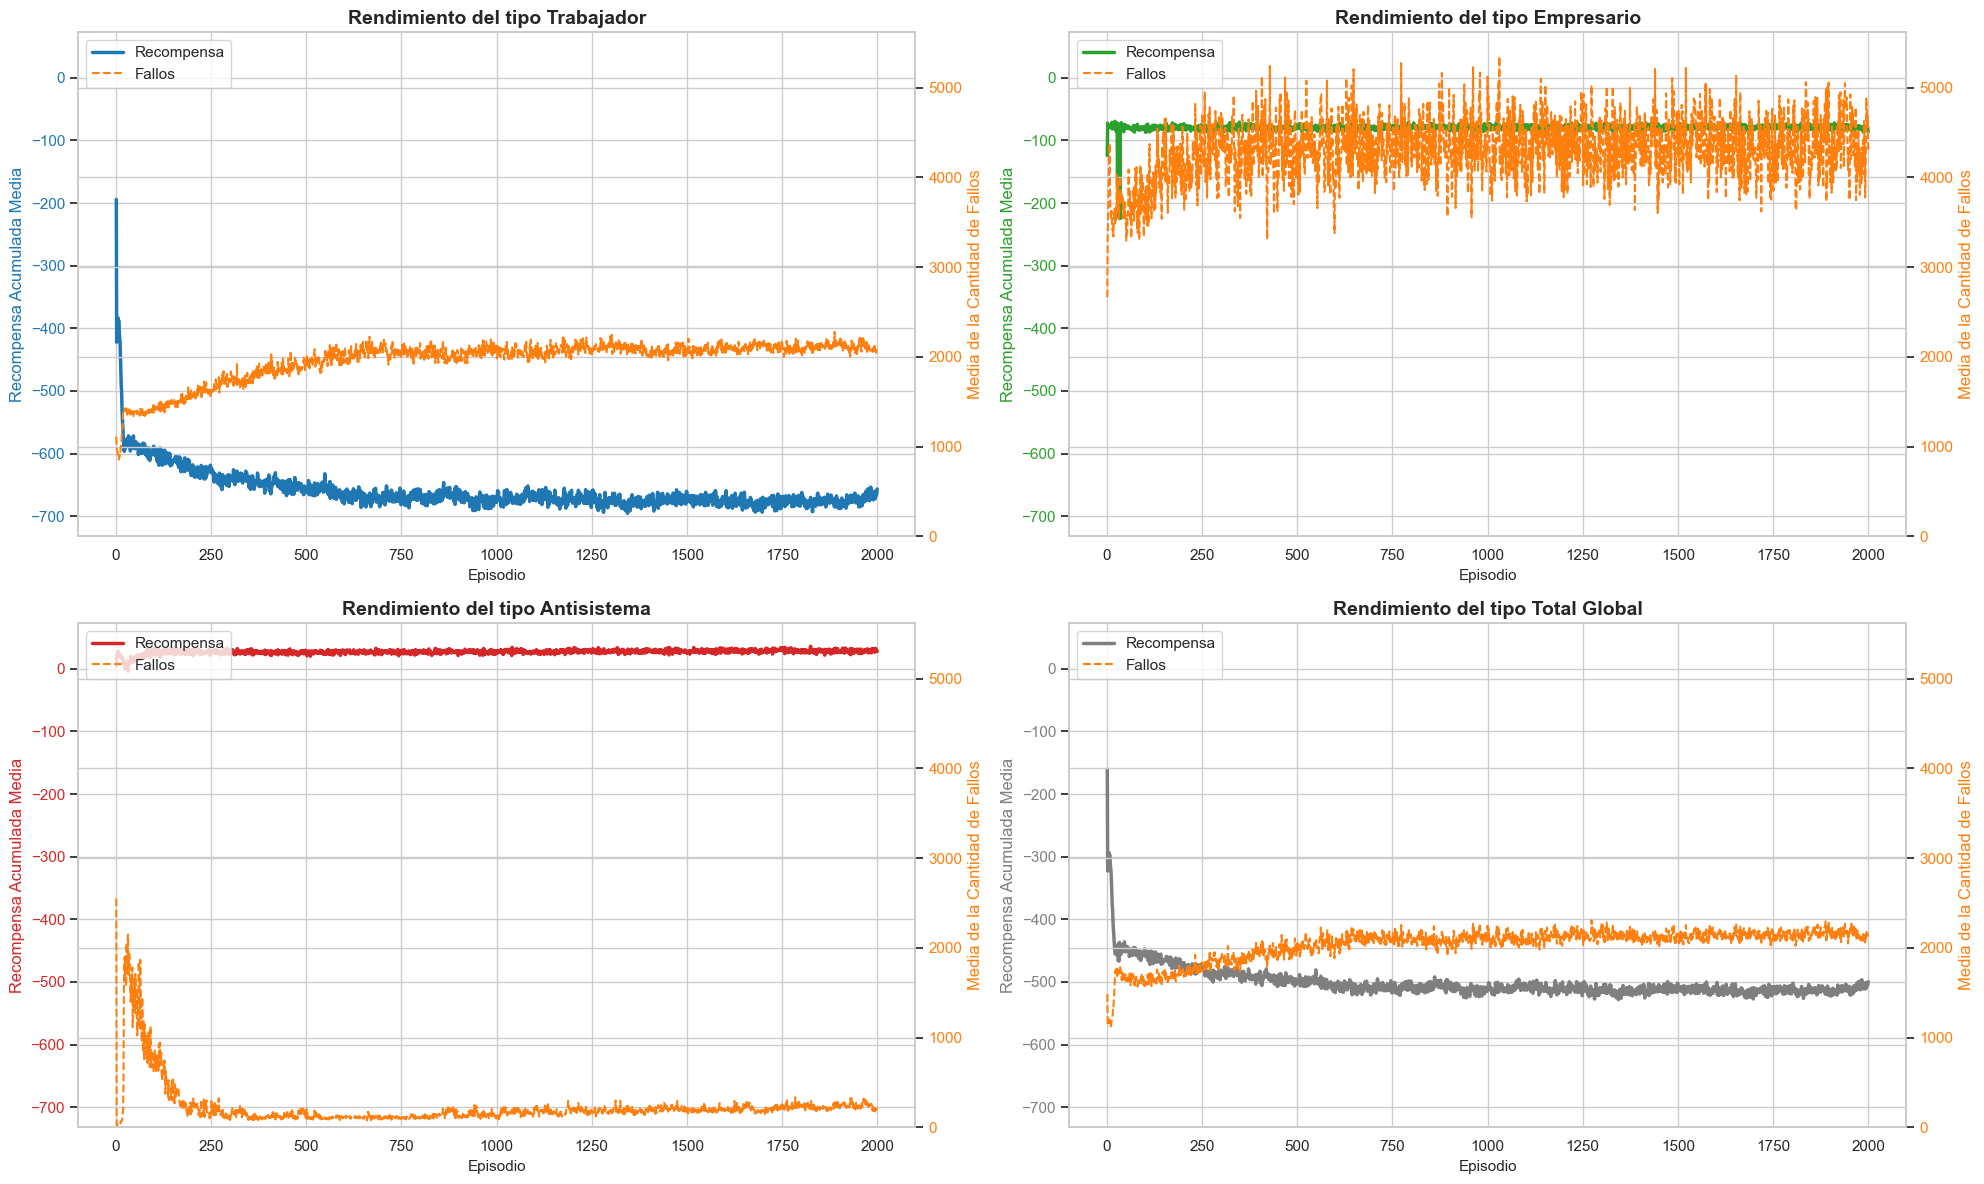

In [4]:
#Cuadrícula de 2x2 para las 4 categorías
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

#Lista de las categorías
categorias = ["Trabajador", "Empresario", "Antisistema", "Total"]
coloresRecompensa = ["#1f77b4", "#2ca02c", "#d62728", "#7f7f7f"] 


#Para el eje Izquierdo, buscamos el mínimo y máximo de todas las recompensas
columnasRelevantes = ["Trabajador", "Empresario", "Antisistema", "Total"]

minRecompensaGlobal = df_recompensas[columnasRelevantes].min().min()
maxRecompensaGlobal = df_recompensas[columnasRelevantes].max().max()

margenRecompensa = (maxRecompensaGlobal - minRecompensaGlobal) * 0.05                                   #Añadimos un 5% de margen
limiteRecompensas = (minRecompensaGlobal - margenRecompensa, maxRecompensaGlobal + margenRecompensa)    #Establecemos el límite con el mínimo y el máximo


#Para el eje derecho, sólo calculamos el máximo porque los fallos siempre empiezan en 0
maxFallosGlobales = df_fallos[columnasRelevantes].max().max()
limiteFallos = (0, maxFallosGlobales * 1.05)                                                            #Añadimos un 5% de margen


for i, cat in enumerate(categorias):
    ax1 = axes[i]
    
    #Sobre el eje izquierdo colocamos la recompensa
    colorRecompensa = coloresRecompensa[i]
    sns.lineplot(
        data=df_recompensas, x="Episodio", y=cat, 
        ax=ax1, color=colorRecompensa, linewidth=2.5, label="Recompensa"
    )
    ax1.set_title(f"Rendimiento del tipo {cat if cat != 'Total' else 'Total Global'}", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Episodio", fontsize=11)
    ax1.set_ylabel("Recompensa Acumulada Media", color=colorRecompensa, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=colorRecompensa)
    
    #Forzamos a que todas las Recompensas compartan la misma escala
    ax1.set_ylim(limiteRecompensas)
    

    #Sobre el eje derecho, colocamos los fallos
    colorFallos = "#ff7f0e" 
    ax2 = ax1.twinx()     
    sns.lineplot(
        data=df_fallos, x="Episodio", y=cat, 
        ax=ax2, color=colorFallos, linewidth=1.5, linestyle="--", label="Fallos"
    )
    ax2.set_ylabel("Media de la Cantidad de Fallos", color=colorFallos, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=colorFallos)
    
    #Forzamos a que todos los Fallos compartan la misma escala
    ax2.set_ylim(limiteFallos)
    
    #Obtenemos las líneas y etiquetas de ambos ejes
    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    
    #Dibujamos la leyenda
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left", frameon=True)
    ax2.get_legend().remove() if ax2.get_legend() else None

#Ajustamos el layout para que no se solapen los gráficos
plt.tight_layout()
plt.show()

## **Gráficos Simulación**

### Evolución de la Felicidad, Dinero y Energía con el paso del Tiempo

Se recopilan los datos más importantes a la hora de determinar el Estado de la Sociedad en cada momento, que son la **Felicidad, Riqueza y Energía** que tienen los Agentes que la poblan, pudiéndose ver la evolución que tiene esta según van realizándose steps.

AttributeError: 'NoneType' object has no attribute 'index'

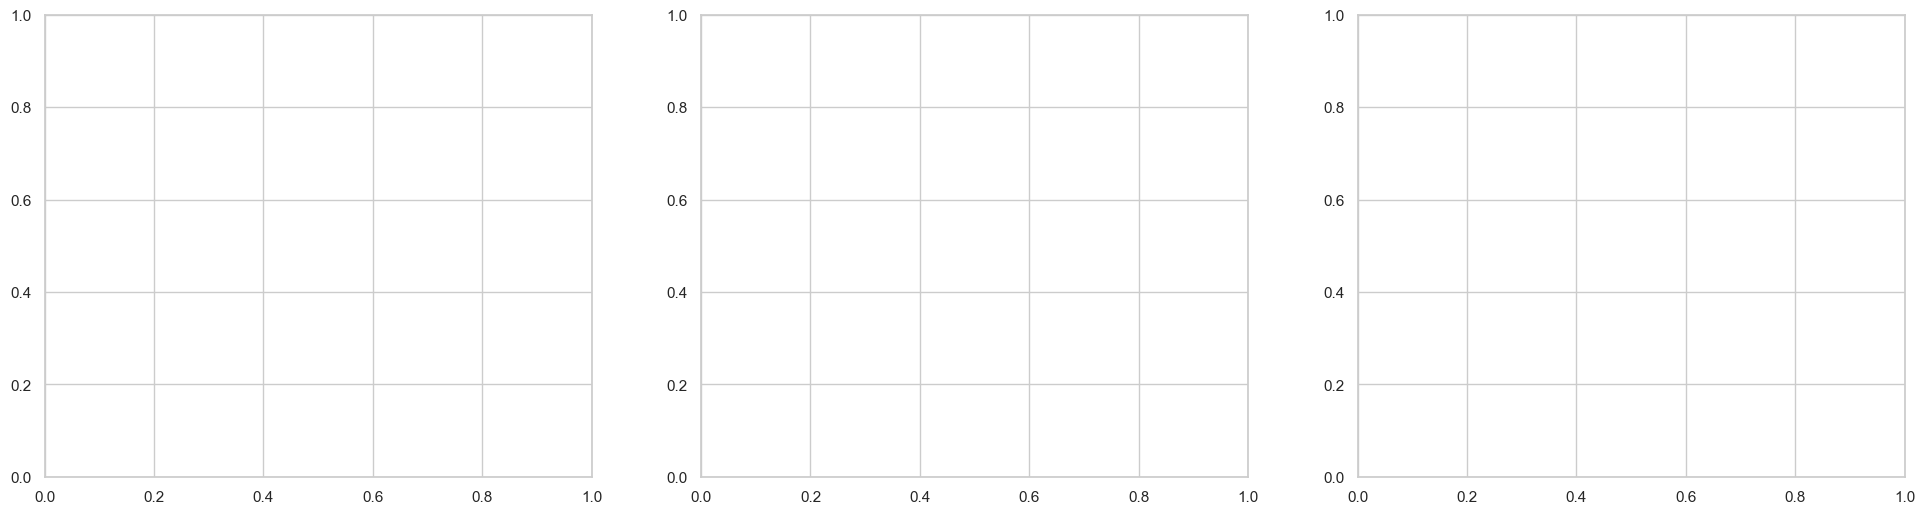

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

#Felicidad Media por tipo de Agente
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Felicidad Media Trabajadores", ax=axes[0], label="Trabajadores", color="blue")
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Felicidad Media Empresarios", ax=axes[0], label="Empresarios", color="green")
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Felicidad Media Antisistema", ax=axes[0], label="Antisistema", color="red")

axes[0].set_title("Evolución de la Felicidad Media por Tipo de Agente")
axes[0].set_ylabel("Felicidad Media")
axes[0].set_xlabel("Paso de tiempo (Step)")


#Dinero Medio por tipo de Agente
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Dinero Medio Trabajadores", ax=axes[1], label="Trabajadores", color="blue")
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Dinero Medio Empresarios", ax=axes[1], label="Empresarios", color="green")
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Dinero Medio Antisistema", ax=axes[1], label="Antisistema", color="red")

axes[1].set_title("Evolución de la Riqueza Media por Tipo de Agente")
axes[1].set_ylabel("Dinero Medio")
axes[1].set_xlabel("Paso de tiempo (Step)")


#Energía Media por tipo de Agente
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Energia Media Trabajadores", ax=axes[2], label="Trabajadores", color="blue")
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Energia Media Empresarios", ax=axes[2], label="Empresarios", color="green")
sns.lineplot(data=df_modelo, x=df_modelo.index, y="Energia Media Antisistema", ax=axes[2], label="Antisistema", color="red")

axes[2].set_title("Evolución de la Energía Media por Tipo de Agente")
axes[2].set_ylabel("Energía Media")
axes[2].set_xlabel("Paso de tiempo (Step)")

#Ajustamos el layout para que no se solapen los gráficos
plt.tight_layout()
plt.show()

### Correlación de Pearson

Analiza la correlación **entre el Dinero y la Felicidad** de los Agentes usando la **Correlación de Pearson**. 

Si el valor es mayor a 0, existe una correlación positiva (cuanto más dinero, mayor felicidad), en cambio, si es menor que 0, existe una correlación negativa (a mayor dinero, menor felicidad). En caso de tener un valor de exactamente 0, no existe ninguna correlación entre el dinero y la felicidad (la variación del dinero no tiene un impacto en la felicidad).

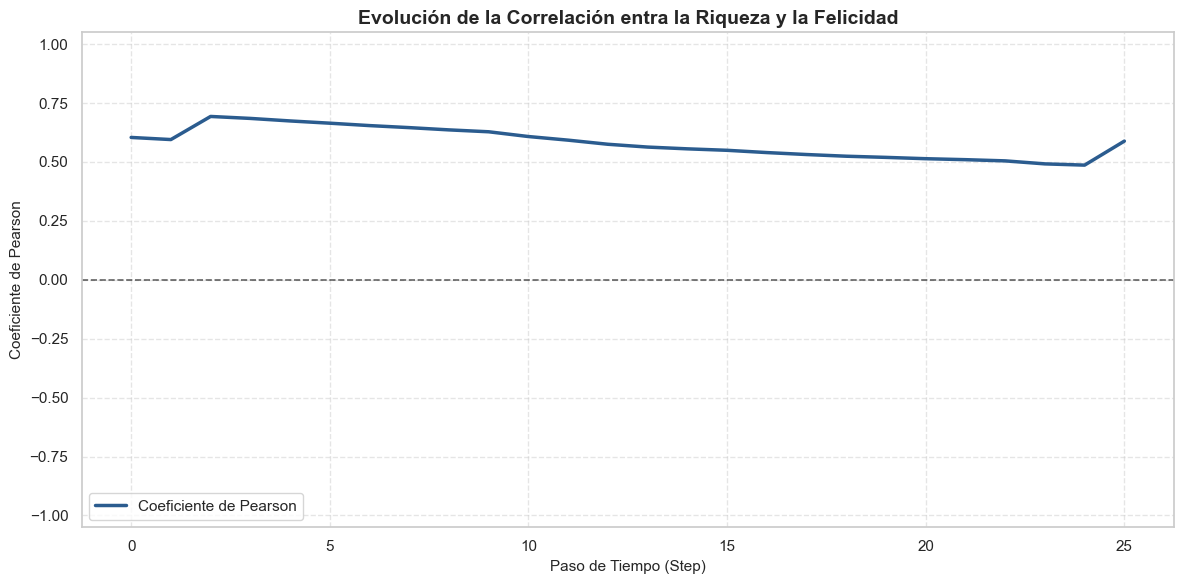

In [ ]:
#Calculamos la correlación entre la Felicidad y el Dinero en cada instante de tiempo
correlacionPearson = (
    df_agentes.groupby("Step")
    .apply(lambda x: x["Felicidad"].corr(x["Dinero"]))
    .reset_index(name="Correlacion")
)

#Rellenamos posibles NaNs con 0.0
correlacionPearson["Correlacion"] = correlacionPearson["Correlacion"].fillna(0.0)


#Definimos cómo se visualizará el gráfico
plt.figure(figsize=(12, 6))

#Dibujamos la línea con la correlación de Pearson
sns.lineplot(
    data=correlacionPearson,
    x="Step",
    y="Correlacion",
    color="#2b5c8f",
    linewidth=2.5,
    label="Coeficiente de Pearson"
)

#Dibujamos una línea de referencia sobre el 0
plt.axhline(0, color="black", linestyle="--", alpha=0.6, linewidth=1.2)



plt.title("Evolución de la Correlación entra la Riqueza y la Felicidad", fontsize=14, fontweight='bold')
plt.xlabel("Paso de Tiempo (Step)", fontsize=11)
plt.ylabel("Coeficiente de Pearson", fontsize=11)

#Forzamos que el eje Y sólo cubra el rango de Pearson [-1, 1]
plt.ylim(-1.05, 1.05)

plt.legend(loc="lower left", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Análisis de Desigualdad Gini

Se calcula la **Desigualdad Económica** que hay entre todos los Agentes en cada step de la Simulación utilizando el **Índice de Gini**.

Si el valor es cercano a 1, existe una gran disparidad entre los distintos Agentes y, en caso de ser cercano a 0, la Sociedad tiende a la equidad.

In [ ]:
#Calculamos el Gini para cada Step
steps = df_agentes['Step'].unique()
evolucionGini = []

for s in steps:
    dineroStep = df_agentes[df_agentes['Step'] == s]['Dinero']
    evolucionGini.append(calcularIndiceGini(dineroStep))


#Definimos las características visuales del gráfico
plt.figure(figsize=(10, 5))
sns.lineplot(x=steps, y=evolucionGini, color="purple", linewidth=2.5)

plt.title("Evolución de la Desigualdad")
plt.xlabel("Step")
plt.ylabel("Coeficiente de Gini (0=Igualdad, 1=Desigualdad)")

plt.ylim(0, 1)
plt.show()

### Distribución de Dinero por Tipo de Agente

Simplemente un Boxplot para poder visualizar la **diferencia monetaria entre cada uno de los tipos de agentes**, pudiéndose también apreciar el agente con mayor Dinero y el agente con menor Dinero para cada Tipo.

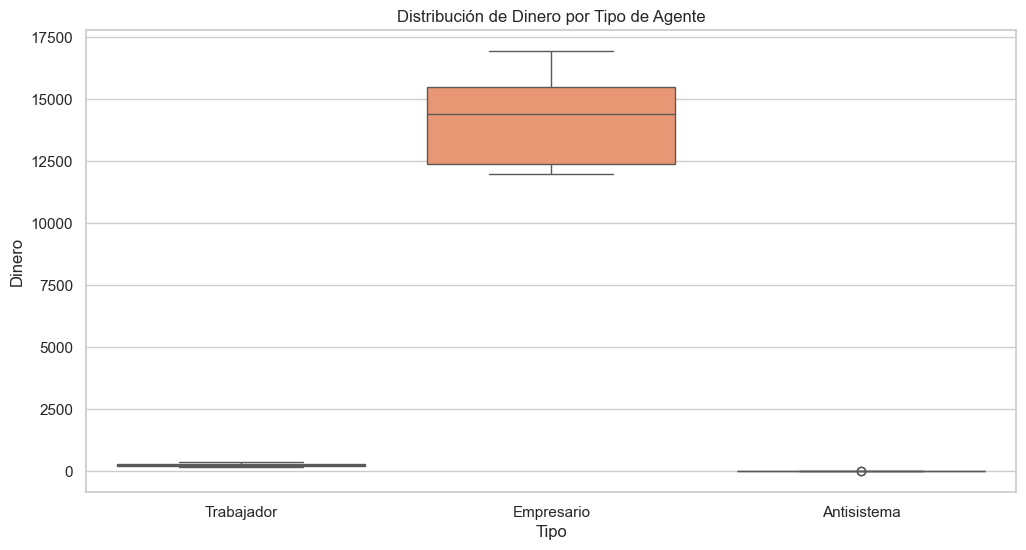

In [ ]:
#Usamos el último step para comparar el dinero de cada Tipo de agente al final de la simulación
ultimoStep = df_agentes['Step'].max()
df_final = df_agentes[df_agentes['Step'] == ultimoStep]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_final, 
    x="Tipo", 
    y="Dinero", 
    hue="Tipo",
    palette="Set2", 
    legend=False
)

plt.title("Distribución de Dinero por Tipo de Agente")
plt.show()